# LSTM Practical — Character Prediction & Temperature Time-Series

This notebook contains two complete LSTM implementations:

1. **Character-Level LSTM** — predicts the next character from a sequence, e.g. `mach → i`.
2. **Temperature Time-Series LSTM** — normalizes temperature data, creates sequences, trains an LSTM, predicts values, and plots actual vs predicted temperatures.

### Install requirements
```bash

```

In [3]:
pip install tensorflow numpy pandas matplotlib scikit-learn

  Using cached tensorflow-2.21.0-cp310-cp310-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached grpcio-1.84.0-cp310-cp310-win_amd64.whl.metadata (3.9 kB)
  Using cached keras-3.12.4-py3-none-any.whl.metadata (6.0 kB)
  Using cached h5py-3.14.0-cp310-cp310-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.6.0-cp310-cp310-win_amd64.whl.metadata (8.8 kB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
Using cached tensorflow-2.21.0-cp310-cp310-win_amd64.whl (350.6 MB)
Using cached grpcio-1.84.0-cp310-cp310-win_amd64.whl (5.3 MB)
Using cached h5py-3.14.0-cp310-cp310-win_amd64.whl (2.9 MB)
Using cached ml_dtypes-0.6.0-cp310-cp310-win_amd64.whl (433 kB)
Using cached numpy-2.2.6-cp310-cp310-win_amd64.wh

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Users\\aswin\\OneDrive\\Desktop\\sem 6\\dtaModel\\dtaModel\\.venv\\Lib\\site-packages\\tensorflow\\python\\_pywrap_tensorflow_common.dll'
Check the permissions.


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Character-Level LSTM

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

print("TensorFlow version:", tf.__version__)

  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 2.4/350.6 MB 14.9 MB/s eta 0:00:24
   ---------------------------------------- 3.1/350.6 MB 14.2 MB/s eta 0:00:25
    --------------------------------------- 4.5/350.6 MB 7.5 MB/s eta 0:00:47
    --------------------------------------- 6.3/350.6 MB 8.4 MB/s eta 0:00:42
    --------------------------------------- 7.1/350.6 MB 6.9 MB/s eta 0:00:50
    --------------------------------------- 7.9/350.6 MB 6.2 MB/s eta 0


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


TensorFlow version: 2.21.0


### 1.1 Training Text and Character Encoding

In [6]:
text = (
    "machine learning is interesting "
    "machine learning is powerful "
    "machine learning is useful "
    "deep learning uses neural networks "
    "artificial intelligence is changing the world "
).lower()

chars = sorted(list(set(text)))
char_to_int = {c: i for i, c in enumerate(chars)}
int_to_char = {i: c for i, c in enumerate(chars)}

print("Characters:", chars)
print("Number of unique characters:", len(chars))

Characters: [' ', 'a', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'w']
Number of unique characters: 20


### 1.2 Create Input Sequences

In [7]:
seq_length = 4

X = []
y = []

for i in range(len(text) - seq_length):
    sequence = text[i:i + seq_length]
    target = text[i + seq_length]

    X.append([char_to_int[c] for c in sequence])
    y.append(char_to_int[target])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (165, 4)
y shape: (165,)


### 1.3 One-Hot Encoding

In [8]:
num_chars = len(chars)

X = tf.keras.utils.to_categorical(X, num_classes=num_chars)
y = tf.keras.utils.to_categorical(y, num_classes=num_chars)

print("X shape after one-hot encoding:", X.shape)
print("y shape after one-hot encoding:", y.shape)

X shape after one-hot encoding: (165, 4, 20)
y shape after one-hot encoding: (165, 20)


### 1.4 Build and Train Character LSTM

In [9]:
char_model = Sequential([
    LSTM(128, input_shape=(seq_length, num_chars)),
    Dense(num_chars, activation="softmax")
])

char_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

char_model.summary()

c:\Users\aswin\OneDrive\Desktop\sem 6\dtaModel\dtaModel\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        76,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,868 (308.08 KB)

 Trainable params: 78,868 (308.08 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
char_history = char_model.fit(
    X,
    y,
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.1333 - loss: 2.9821
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2545 - loss: 2.9326
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2364 - loss: 2.8702
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2606 - loss: 2.7770
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1818 - loss: 2.6410
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2424 - loss: 2.5422
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2848 - loss: 2.4508
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3152 - loss: 2.3792
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2667 - loss: 2.3022
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2970 - loss: 2.2308
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3394 - loss: 2.1709
Epoch 12/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step

### 1.5 Predict the Next Character

In [11]:
def predict_next_char(sequence):
    if len(sequence) != seq_length:
        raise ValueError(f"Input must contain exactly {seq_length} characters.")

    encoded = [char_to_int[c] for c in sequence]
    encoded = tf.keras.utils.to_categorical(
        encoded, num_classes=num_chars
    )
    encoded = np.expand_dims(encoded, axis=0)

    probabilities = char_model.predict(encoded, verbose=0)
    predicted_index = np.argmax(probabilities[0])

    return int_to_char[predicted_index]


input_sequence = "mach"
predicted = predict_next_char(input_sequence)

print("Input:", input_sequence)
print("Predicted next character:", repr(predicted))

Input: mach
Predicted next character: 'i'


**Expected learning pattern:** `mach → i`.

The exact result can vary because the model is trained on a small text corpus. If necessary, increase the training text or number of epochs.

## 2. Temperature Time-Series Prediction

Workflow:

**Load data → Normalize → Create sequences → Train/Test split → Build LSTM → Train → Predict → Inverse transform → Plot actual vs predicted**

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

### 2.1 Create a Sample Temperature Dataset

In [13]:
# This creates a dataset so the notebook runs without an external CSV.
# If you have your own dataset, skip this cell.

np.random.seed(42)

days = 500

temperature = (
    25
    + 5 * np.sin(np.arange(days) * 2 * np.pi / 30)
    + np.random.normal(0, 0.5, days)
)

df = pd.DataFrame({"Temperature": temperature})
df.to_csv("temperature.csv", index=False)

print(df.head())
print("Number of records:", len(df))

   Temperature
0    25.248357
1    25.970426
2    27.357527
3    28.700441
4    28.598647
Number of records: 500


### Using your own dataset

Your CSV should contain a column called `Temperature`.

```python
df = pd.read_csv("temperature.csv")
```

In [14]:
df = pd.read_csv("temperature.csv")

temperature = df["Temperature"].astype(float).values

print("First 10 temperatures:")
print(temperature[:10])

First 10 temperatures:
[25.24835708 25.9704263  27.35752748 28.70044119 28.59864744 29.21305854
 30.54488899 30.35632684 29.73787228 30.0265626 ]


### 2.2 Normalize the Data

In [15]:
scaler = MinMaxScaler(feature_range=(0, 1))

temperature_scaled = scaler.fit_transform(
    temperature.reshape(-1, 1)
)

print("Original values:")
print(temperature[:5])

print("\nNormalized values:")
print(temperature_scaled[:5])

Original values:
[25.24835708 25.9704263  27.35752748 28.70044119 28.59864744]

Normalized values:
[[0.54958882]
 [0.60759296]
 [0.71901942]
 [0.82689628]
 [0.81871915]]


### 2.3 Create Input Sequences

In [16]:
sequence_length = 10

X = []
y = []

for i in range(len(temperature_scaled) - sequence_length):
    X.append(temperature_scaled[i:i + sequence_length])
    y.append(temperature_scaled[i + sequence_length])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (490, 10, 1)
y shape: (490, 1)


For example, with `sequence_length = 3`:

```text
20, 21, 22 → 23
21, 22, 23 → 24
22, 23, 24 → 25
```

The previous values are used to predict the next value.

### 2.4 Train-Test Split

In [17]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training input shape:", X_train.shape)

Training samples: 392
Testing samples: 98
Training input shape: (392, 10, 1)


### 2.5 Build the Temperature LSTM

In [18]:
temp_model = Sequential([
    LSTM(64, input_shape=(sequence_length, 1)),
    Dense(1)
])

temp_model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

temp_model.summary()

c:\Users\aswin\OneDrive\Desktop\sem 6\dtaModel\dtaModel\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

### 2.6 Train the Model

In [19]:
temp_history = temp_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - loss: 0.1571 - val_loss: 0.0787
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0626 - val_loss: 0.0700
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0474 - val_loss: 0.0466
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0352 - val_loss: 0.0304
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0180 - val_loss: 0.0087
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0048 - val_loss: 0.0030
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0028 - val_loss: 0.0026
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0024 - val_loss: 0.0028
Epoch 10/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0022 - val_loss: 0.0024
Epoch 11/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0022 - val_loss: 0.0024
Epoch 12/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0

### 2.7 Plot Training and Validation Loss

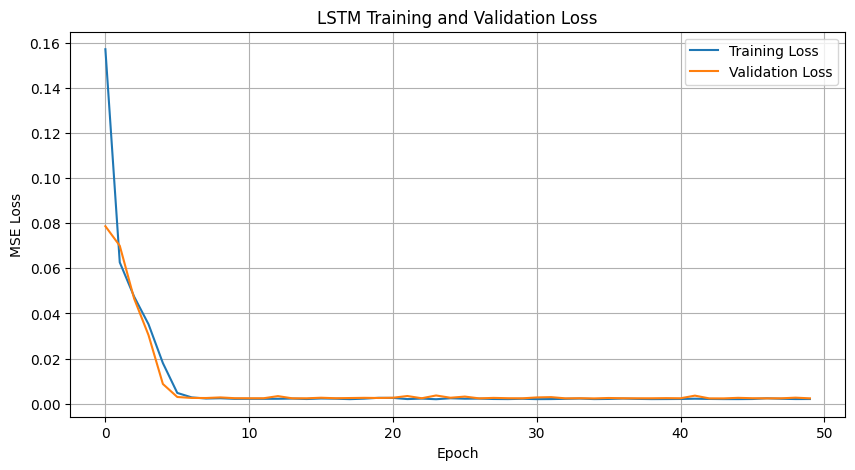

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(temp_history.history["loss"], label="Training Loss")
plt.plot(temp_history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

### 2.8 Predict Test Temperatures

In [21]:
predicted_scaled = temp_model.predict(X_test)

# Convert normalized values back to original temperature scale
predicted = scaler.inverse_transform(predicted_scaled)
actual = scaler.inverse_transform(y_test)

print("First 10 actual temperatures:")
print(actual[:10].flatten())

print("\nFirst 10 predicted temperatures:")
print(predicted[:10].flatten())

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step
First 10 actual temperatures:
[27.94154811 27.05717351 25.81452572 25.31142497 23.42663133 22.89512704
 22.12122155 21.54149529 21.02568042 19.68239637]

First 10 predicted temperatures:
[27.86649  26.843702 26.026333 25.065462 24.053387 22.886774 22.061872
 21.296131 20.85144  20.425343]


### 2.9 Actual vs Predicted Plot

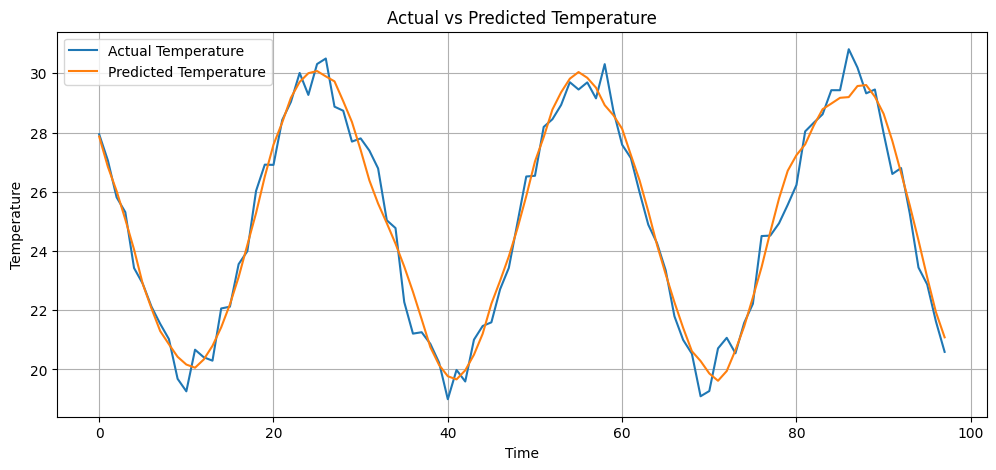

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(actual, label="Actual Temperature")
plt.plot(predicted, label="Predicted Temperature")

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()

# Quick Viva Revision

### Character LSTM
- **Input:** sequence of characters
- **Output:** next character
- Example: `mach → i`
- **Softmax:** gives probability for every possible character.

### Temperature LSTM
- **Normalization:** scales values, commonly to 0–1.
- **Sequence length:** number of previous values used to predict the next value.
- **LSTM:** learns patterns/dependencies in sequential data.
- **Dense(1):** outputs one continuous temperature value.
- **MSE:** regression loss function.
- **Inverse transform:** converts predictions back to the original temperature scale.

### Architecture

```text
Temperature sequence
        ↓
      LSTM
        ↓
     Dense(1)
        ↓
Next temperature
```